### 성적데이터 생성

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.DataFrame({'시간' : [2, 4, 8, 9],       # X : 특성 데이터
                     '성적' : [20, 40, 80, 90]})  # y : 실제값(타겟)
data

# y = wx + b -> w와 b값을 찾아 직선을 그어야 한다! 

,시간,성적
0,2,20
1,4,40
2,8,80
3,9,90


### 1. 수학적 공식을 이용한 모델
- LinearRegression

In [3]:
# sklearn 모듈에서 불러올거다.
from sklearn.linear_model import LinearRegression # 선형모델 패키지에서  LinearRegression도구를 불러올거다

In [4]:
# 모델 생성(초기화)
linear_model = LinearRegression() # 조정해줄 파라미터는 없다. 수학적 공식을 사용해서 w랑 b값을 계속 바꿔가면서 최적의 선을 알아서 파악하기 때문.

In [6]:
# 모델 학습 시키기
# 모델명.fit(X, y) # X는 특성값들이 여러개가 될거기 때문에 대문자로 썼다.
linear_model.fit(data[['시간']], data['성적'])       # 표가 2차원 형식인데 X는 특성값이 여러개가 될수 있기 때문에 대괄호를 두개 사용했다.
                                                    #  LinearRegression도구는 X값에 무조건 2차원 형식의 데이터가 들어올것으로 생각해서 대괄호를 두개 써줘야 한다.
                                                    #  LinearRegression도구 y값에 컬럼이 2개가 된다고 해도 무조건 대괄호 하나만 써야한다.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['시간']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.105e-15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
# 모델이 w값과 b값을 찾았대 !
# 모델이 설정한 w값과 b값을 확인해보자!

# w값 확인
print(linear_model.coef_) # w값. 가중치를 확인 coef(coefficient의 약자) 
# coef_ 함수 끝에  언더바는 모델이 스스로 생각한 결과를 나타내주는 함수 라는 표시이다.
# 특성이 여러개이면 가중치도 여러개 이기 때문에 w값이 리스트[]에 묶여서 나온다.
# --> 지금은 X값이 하나지만 늘어날때를 대비해서 첨부터 리스트에 담아두는 것.

# b값 확인
print(linear_model.intercept_) # 절편(intercept)
# b값을 복사해서 ai한테 물어보면 알려주는데 지금 나온값은 0에 매우 가깝기 때문에 사실상 0으로 봐도 무방하다

# 값 최종 해석 : y = 10x + 0


[10.]
7.105427357601002e-15


In [8]:
# 모델을 만들었으니 예측을 해보자
# 모델명.predict(X_test)
# train_test_split으로 테스트용 특성값을 나눈게 없기 때문에 임의로 값을 넣어보자
linear_model.predict([[7]]) #특성값이 여러개인 경우가 많기 때문에 대괄호 두개씩.
# 빨간창은 에러는 아니고, 데이터를 하나만 넣지 말고, 데이터 형태로 넣어줘라~ 라는 뜻이다. 경고창.

C:\Users\smhrd\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([70.])

In [9]:
# 모델 평가를 해보자
# [선형 회귀의 평가 방식과 오차 계산의 필요성]

# 1. 왜 정확도(Accuracy)를 쓰면 안 될까?
# - 선형 회귀는 연속된 숫자를 맞히는 모델이라 '정확도'로 평가할 수 없습니다.
# - 만약 10개의 데이터 중 9개를 완벽히 맞히고 1개만 살짝 빗나가도, 
#   분류 모델식의 단순 '정확도' 개념을 적용하면 0점(0%)이 될 수 있기 때문입니다.

# 2. 오차를 구할 때 '절대값'이나 '제곱'을 쓰는 이유
# - 오차(Error) = 예측값(H(x)) - 실제값(y)
# - 예측값이 실제값보다 작으면 오차가 마이너스(-)로 나올 수 있습니다.
# - 이 마이너스 오차들을 그대로 다 더해버리면 플러스 값과 상쇄되어 
#   실제로는 오차가 큰데도 전체 합이 '0'이 되어버리는 문제가 발생합니다.
# - 따라서 정확한 평가를 위해 오차에 절대값(MAE 등)을 씌우거나 제곱(MSE 등)을 해줍니다.


In [10]:
# [선형 회귀의 예측값 구하는 공식 (가설 함수, Hypothesis)]
# 
# 1. 기본 공식
# H(x) = w * x + b
# - H(x): 모델이 계산해 낸 '예측값' (Hypothesis의 약자)
# - w (가중치, coef_): 특성이 결과에 미치는 영향력 (기울기)
# - x (특성값): 우리가 입력하는 독립 변수 (예: 공부 시간)
# - b (절편, intercept_): 모든 특성이 0일 때 가지는 기본값 (y절편)
#
# 2. 이번 실습 예시에 대입해 보면:
# - 우리가 찾은 w = 10, b = 0 이므로
# - H(x) = 10 * x + 0
# - 만약 7시간을 넣는다면(x = 7), H(7) = 10 * 7 + 0 = 70 이라는 예측값이 나옵니다.

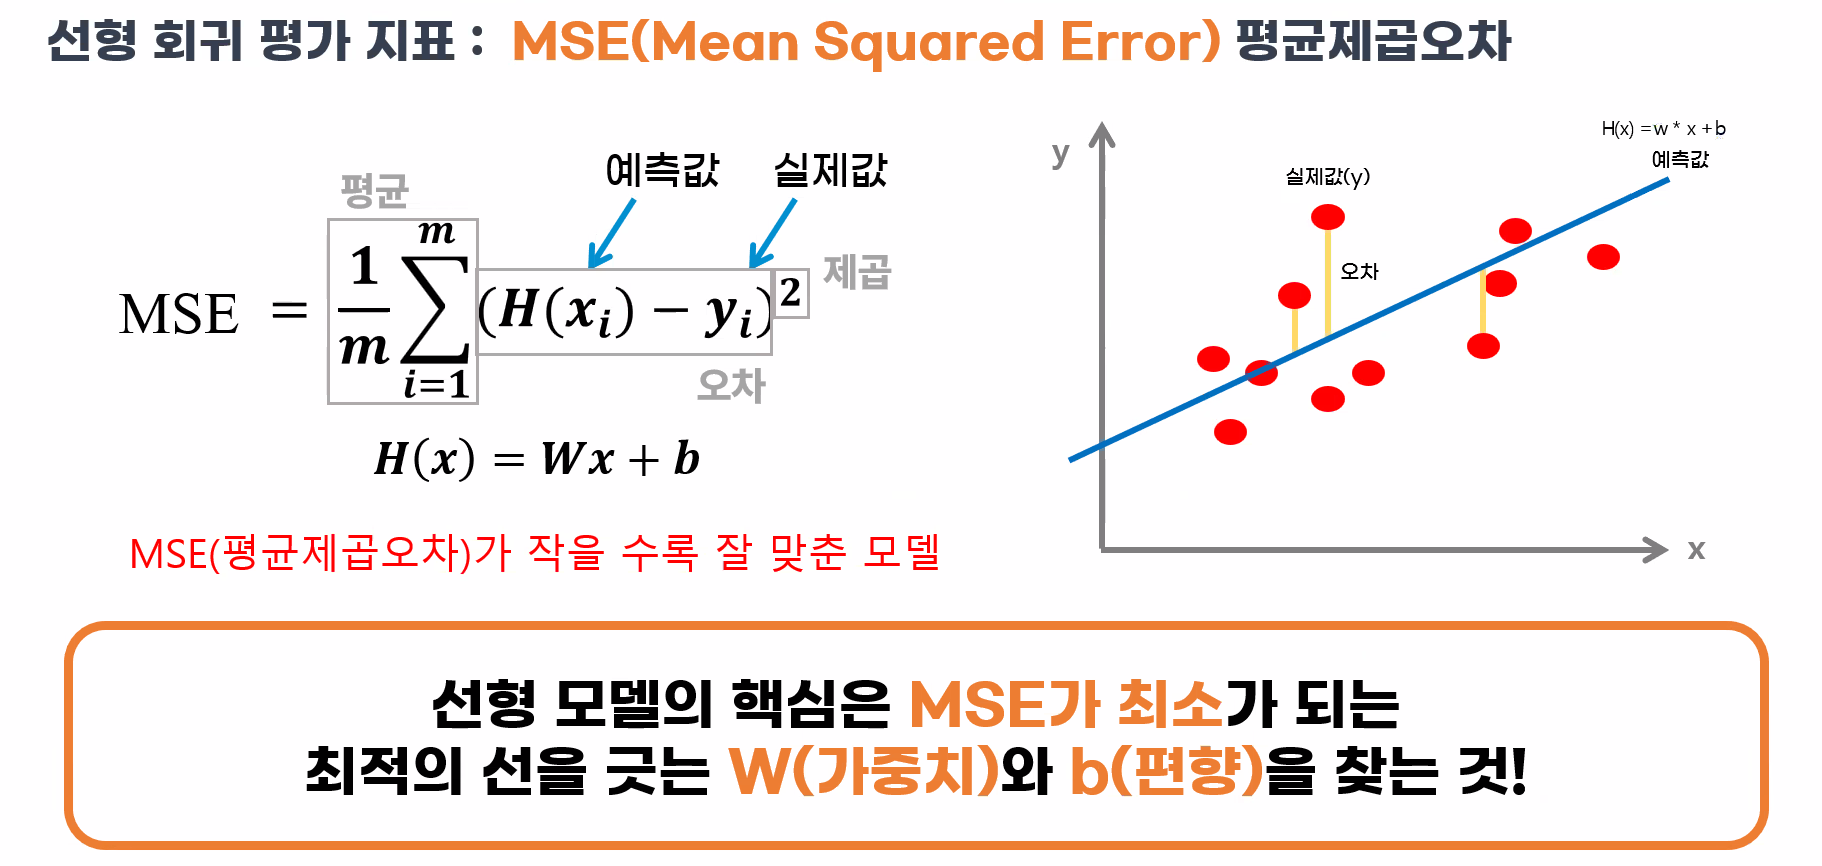

In [11]:
# [시그마(Σ) 기호의 의미와 MSE 공식 풀이]
# 
# 1. 시그마(Σ, Summation)란?
# - 데이터가 여러 개(첫 번째부터 m번째까지) 있을 때, 
#   그 여러 개의 값들을 '전부 다 더하라'는 뜻의 수학 기호입니다.
#
# 2. MSE(평균제곱오차) 공식에 적용해 보면:
# - (H(x_i) - y_i)^2 : 각 데이터마다 구한 오차의 제곱값
# - i = 1 부터 m 까지 : 첫 번째 데이터부터 마지막(m개) 데이터까지 각각 오차를 구하고,
# - Σ (시그마) : 그 모든 오차 제곱 값들을 전부 다 더한 뒤,
# - 1/m : 전체 데이터 개수(m)로 나누어 '평균'을 구한다는 뜻입니다.
# 
# 즉, "모든 데이터들의 오차 제곱을 구해서 다 더한 뒤 평균을 낸 값"이 바로 MSE입니다.

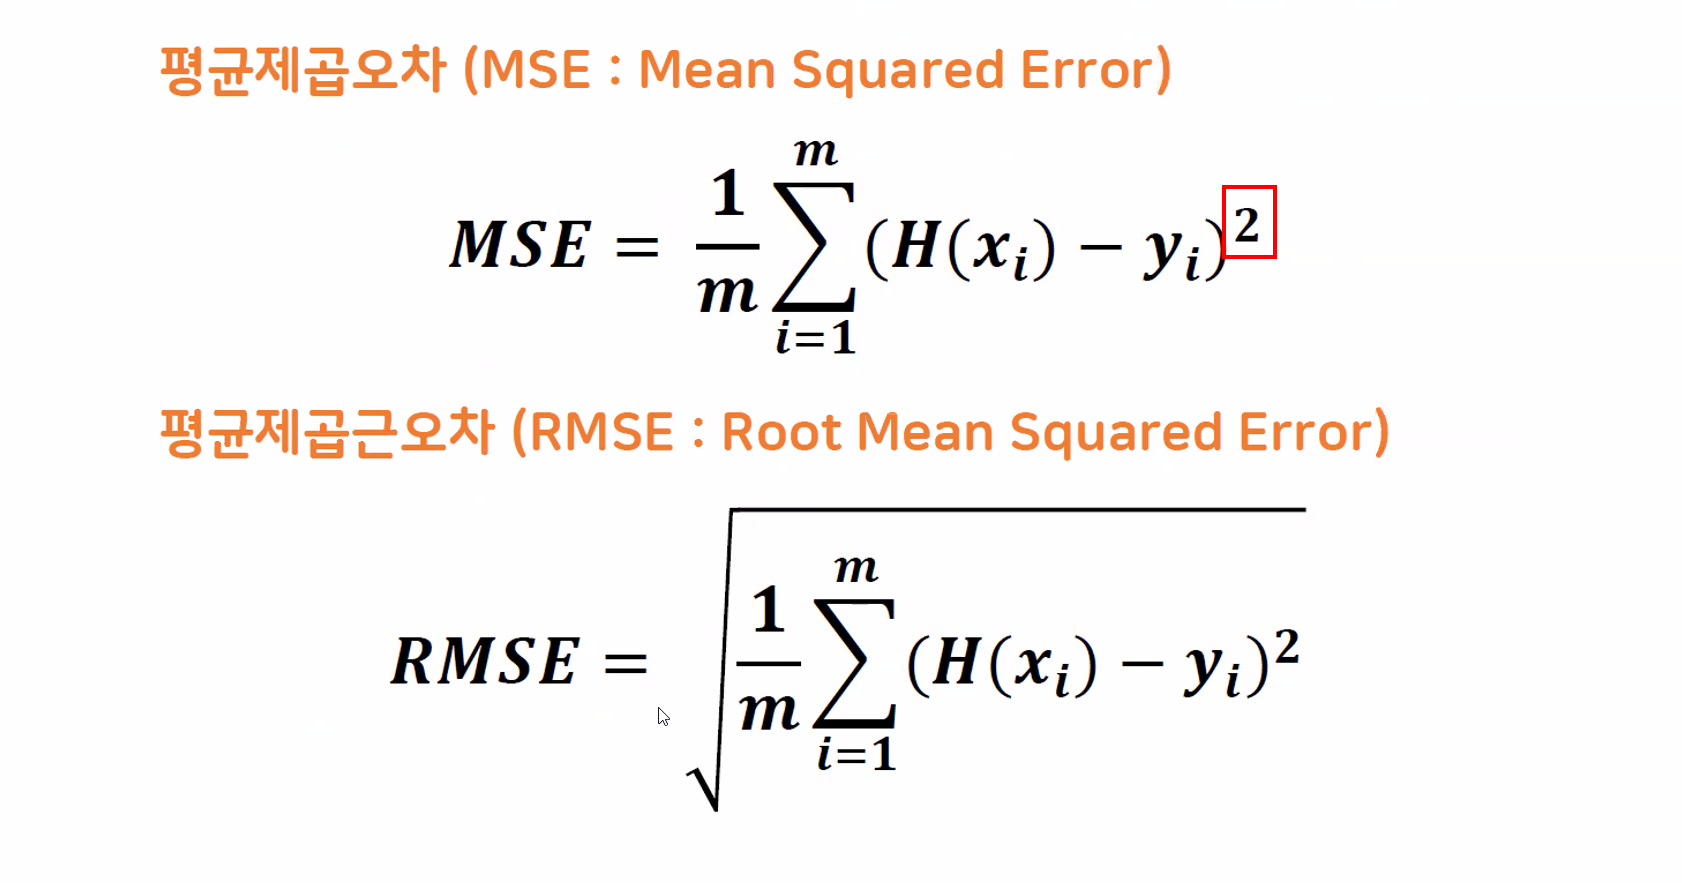

In [13]:
# [RMSE(평균 제곱근 오차, Root Mean Squared Error)의 특징과 한계]
# 
# 1. RMSE의 장점 (등장 이유)
# - MSE(평균제곱오차)는 오차를 제곱하기 때문에 값이 너무 부풀려지고 원래 단위와 달라지는 문제가 생깁니다.
# - RMSE는 MSE 값에 제곱근(Root)을 씌워주어, 부풀려졌던 수치를 다시 원래 데이터의 단위와 
#   비슷한 크기로 되돌려 놓기 때문에 모델의 성능을 직관적으로 이해하고 해석하기가 훨씬 수월합니다.
# 
# 2. RMSE의 단점 / 한계점
# - 첫째, 이상치(Outlier)에 취약합니다. 오차를 제곱하는 과정을 거치기 때문에 크게 빗나간 
#   데이터가 하나만 있어도 전체 RMSE 값이 무지막지하게 커져 성능을 왜곡할 수 있습니다.
# - 둘째, 데이터의 절대적인 스케일(크기)을 고려하지 못합니다. 
#   네이버(주가 20만 원)와 삼성전자(주가 7만 원)의 RMSE가 똑같이 5,000이 나오더라도 
#   실제 체감하는 오차율(비율)은 다르기 때문에, 스케일이 다른 모델 간의 
#   직접적인 절대적 비교가 어렵다는 한계가 있습니다.

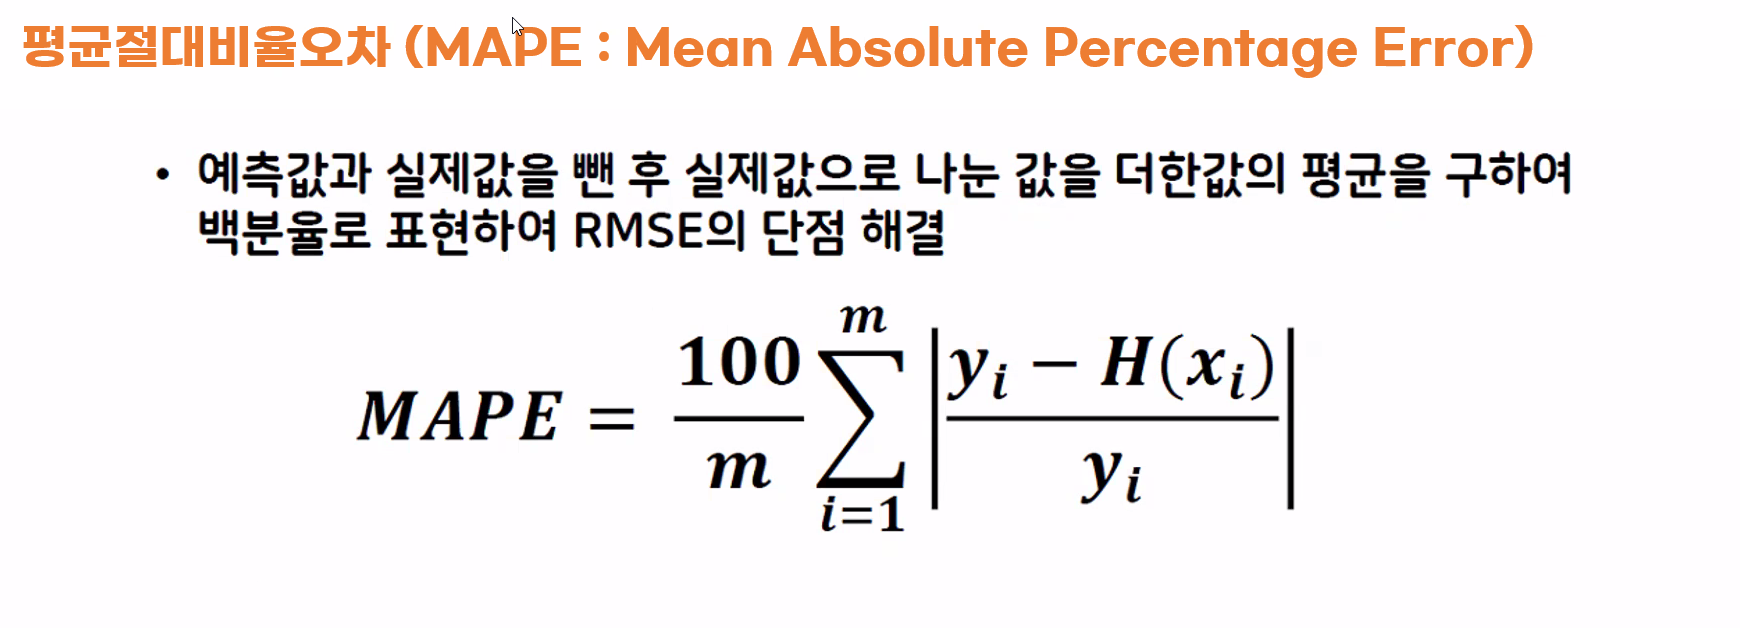

In [ ]:
# [MAPE (평균 절대 비율 오차, Mean Absolute Percentage Error)의 특징과 한계]
# 
# 1. MAPE가 나온 이유 (장점)
# - MSE나 RMSE는 절대적인 수치로만 오차를 보여주기 때문에 스케일이 다른 모델끼리 비교하기 어렵다는 단점이 있었습니다.
# - MAPE는 오차를 실제값($y_i$)으로 나누어 **퍼센트(%) 비율**로 계산하기 때문에, 
#   데이터의 단위나 크기에 상관없이 모델의 성능을 직관적으로 비교할 수 있습니다.
# 
# 2. MAPE의 치명적인 단점 (한계점)
# - 분모에 실제값($y_i$)이 들어가기 때문에, 만약 **실제 데이터($y_i$)의 값이 0**인 경우가 존재한다면 
#   수학적으로 **0으로 나누는 연산(Division by Zero)**이 발생하여 에러가 나거나 값이 무한대로 튀어버리는 문제가 생깁니다.
# - 따라서 실제값에 0이 포함될 수 있는 데이터셋에서는 사용하기 어렵다는 한계가 있습니다.

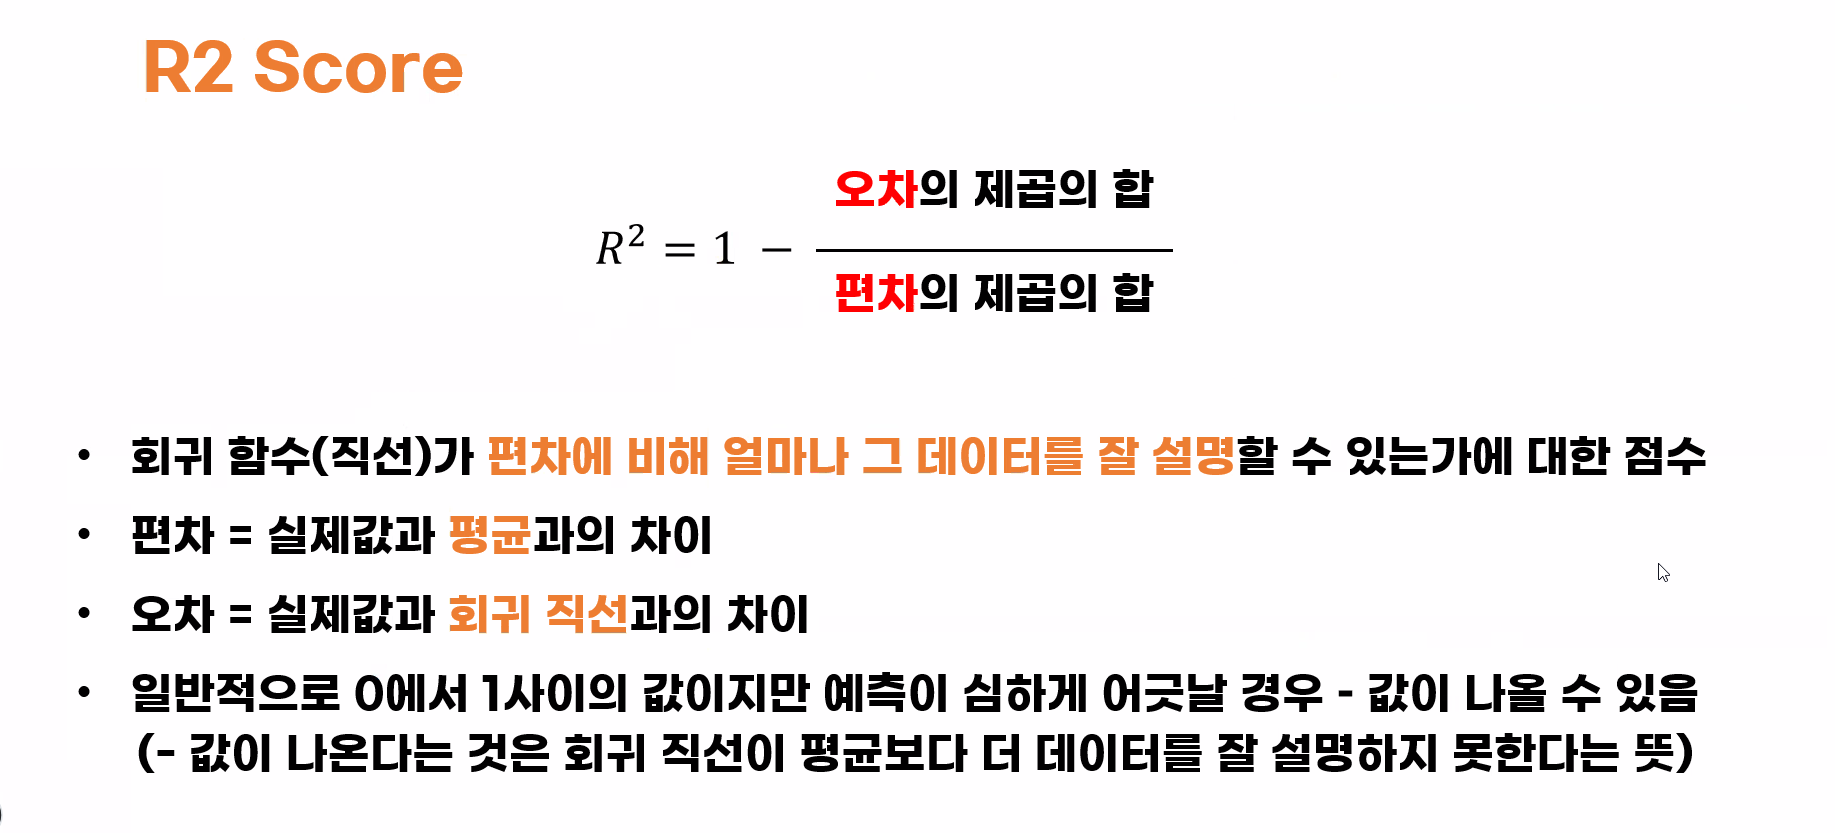

In [14]:
# [R2 스코어 (결정계수, R-Squared) 구하는 공식과 원리]
# 
# 1. R2 스코어의 기본 계산 공식
# - R2 = 1 - (잔차 제곱의 합 / 총 제곱의 합)
# - 즉, R2 = 1 - (SS_res / SS_tot)
# 
# 2. 공식에 사용되는 핵심 개념
# - SS_res (Residual Sum of Squares, 잔차 제곱의 합):
#   * 우리가 만든 회귀 직선(예측값)이 실제 데이터들을 얼마나 맞히지 못했는지(오차)를 제곱해서 다 더한 값입니다. (모델의 오차)
# - SS_tot (Total Sum of Squares, 총 제곱의 합):
#   * 데이터의 실제값들과 '평균선' 사이의 차이를 제곱해서 다 더한 값입니다. (기준선과의 오차)
# 
# 3. 공식이 작동하는 원리
# - 만약 모델이 엉터리여서 평균선만큼의 예측도 못 한다면 SS_res가 SS_tot보다 커져서 
#   (SS_res / SS_tot) 값이 1보다 커지고, 결국 1에서 빼면 음수(-)가 됩니다.
# - 반대로 모델이 완벽하게 데이터를 다 맞혀서 오차(잔차)가 0이 된다면, 
#   SS_res가 0이 되므로 1 - (0 / SS_tot) = 1 - 0 = 1 (즉, 100%)이 됩니다.

In [16]:
# [머신러닝 회귀 모델 평가 지표, 과연 무엇이 제일 좋을까?]
# 
# 1. 절대적인 '최고'의 지표는 없습니다. 데이터의 특성과 목적에 따라 골라 써야 합니다.
# 
# 2. 실무에서 가장 흔하게 많이 쓰는 국룰 조합:
# - RMSE (평균 제곱근 오차): 
#   * 원래 데이터와 같은 단위를 쓰기 때문에 모델의 성능을 직관적으로 파악하기 가장 좋습니다. 
#   * 단, 주가나 매출처럼 스케일이 다르면 비교가 어렵고 큰 이상치(Outlier)에 민감하다는 단점이 있습니다.
# - R2 스코어 (결정계수): 
#   * "우리 모델이 평균선보다 얼마나 데이터를 잘 설명하는지"를 0~1 사이(또는 백분율)의 
#   * 직관적인 점수로 보여주기 때문에 모델의 전반적인 적합도를 평가할 때 필수로 함께 확인합니다.
# 
# 3. 상황별 추천 선택 가이드:
# - 데이터에 이상치가 많고 오차의 비율(%)을 중요하게 보고 싶다 -> MAPE 사용
# - 직관적인 오차 크기(단위)로 성능을 체감하고 싶다 -> RMSE 사용
# - 모델이 데이터를 전체적으로 얼마나 잘 설명하는지(설명력)를 보고 싶다 -> R2 스코어 사용

### 2. 경사하강법
- 가중치(w)변화에 따른 비용함수(MSE, cost)값의 변화 그래프를 그려보자!

In [29]:
# [컴퓨터가 한 번에 계산해주는데도 경사하강법을 알아야 하는 이유]
# 
# 1. 데이터가 너무 많을 때 (메모리 부족 문제)
# - 수학적 공식(LinearRegression)은 모든 데이터를 한 번에 메모리에 올려놓고 계산해야 합니다.
# - 하지만 데이터가 수천만 건, 수억 건처럼 엄청나게 많으면 컴퓨터 메모리가 터져버립니다.
# - 반면 경사하강법은 데이터를 조금씩(또는 한 개씩) 나눠서 학습할 수 있기 때문에 
#   거대한 빅데이터나 딥러닝 환경에서도 문제없이 작동할 수 있습니다.
# 
# 2. 정답 공식이 존재하지 않는 복잡한 문제 (인공신경망/딥러닝)
# - 단순한 선형 회귀는 수학 공식으로 한 방에 딱 떨어지지만, 
#   이미지 인식, 음성 인식, 챗봇 같은 복잡한 딥러닝 모델들은 
#   "한 번에 딱 답을 구하는 수학 공식" 자체가 세상에 존재하지 않습니다.
# - 따라서 정답을 모를 때 조금씩 오차를 줄여가며 찾아가는 '경사하강법'이 
#   인공지능의 핵심 학습 원리로 쓰이게 됩니다.
# 
# 요약하자면, 
# - 데이터가 적을 때는 수학 공식(LinearRegression)이 훨씬 편하고 빠르지만,
# - **데이터가 상상할 수 없이 많거나, 훨씬 복잡한 인공지능(딥러닝)을 다룰 때**는 
#   경사하강법만이 유일한 해결책이기 때문에 반드시 알아야 합니다.

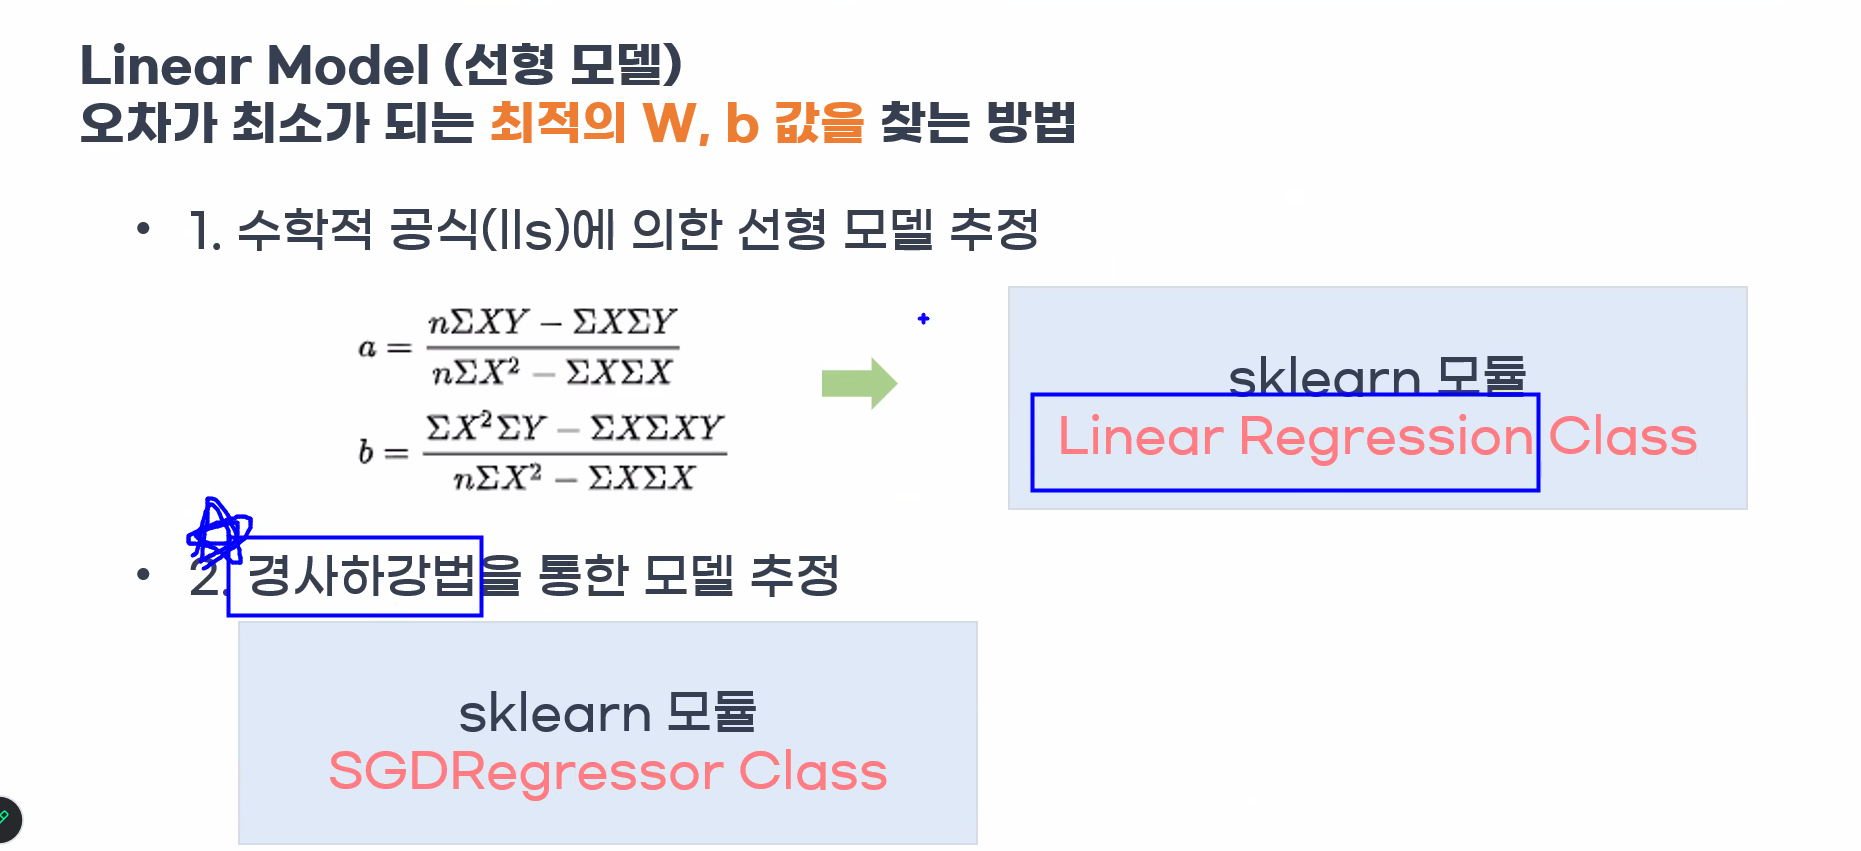

In [ ]:
# [경사하강법 (Gradient Descent Algorithm)의 원리와 중요성]
# 
# 1. 경사하강법이란?
# - MSE(비용함수)의 값을 최소로 만드는 W(가중치)와 b를 찾아가는 최적화 방법입니다[cite: 1].
# - 딥러닝에서도 핵심으로 쓰이기 때문에 매우 중요합니다[cite: 1].
# 
# 2. 이름의 유래와 쉬운 비유
# - 산 정상에서 눈을 가리고 발로 경사를 조금씩 느껴가며 가장 낮은 곳으로 하강하는 모습에서 유래했습니다[cite: 1].
# - 발로 디뎌봤을 때 경사가 가파르면 "아직 정산 근처(위쪽)구나" 하고 판단하고, 
#   발판이 평평해지면 "여기가 오차가 가장 적은 최저점(바닥)이구나" 하고 멈추는 원리입니다[cite: 1].
# 
# 3. 비용함수와 구하는 방법
# - 비용함수(MSE)는 오차를 뜻하므로 값이 **낮을수록 좋습니다**[cite: 1].
# - 즉, 현재 위치에서 비용함수의 기울기(경사)를 구한 뒤[cite: 1], 
#   기울기가 낮아지는 방향으로 조금씩 이동하면서[cite: 1] 오차가 가장 작은 최적의 값을 찾아내게 됩니다.

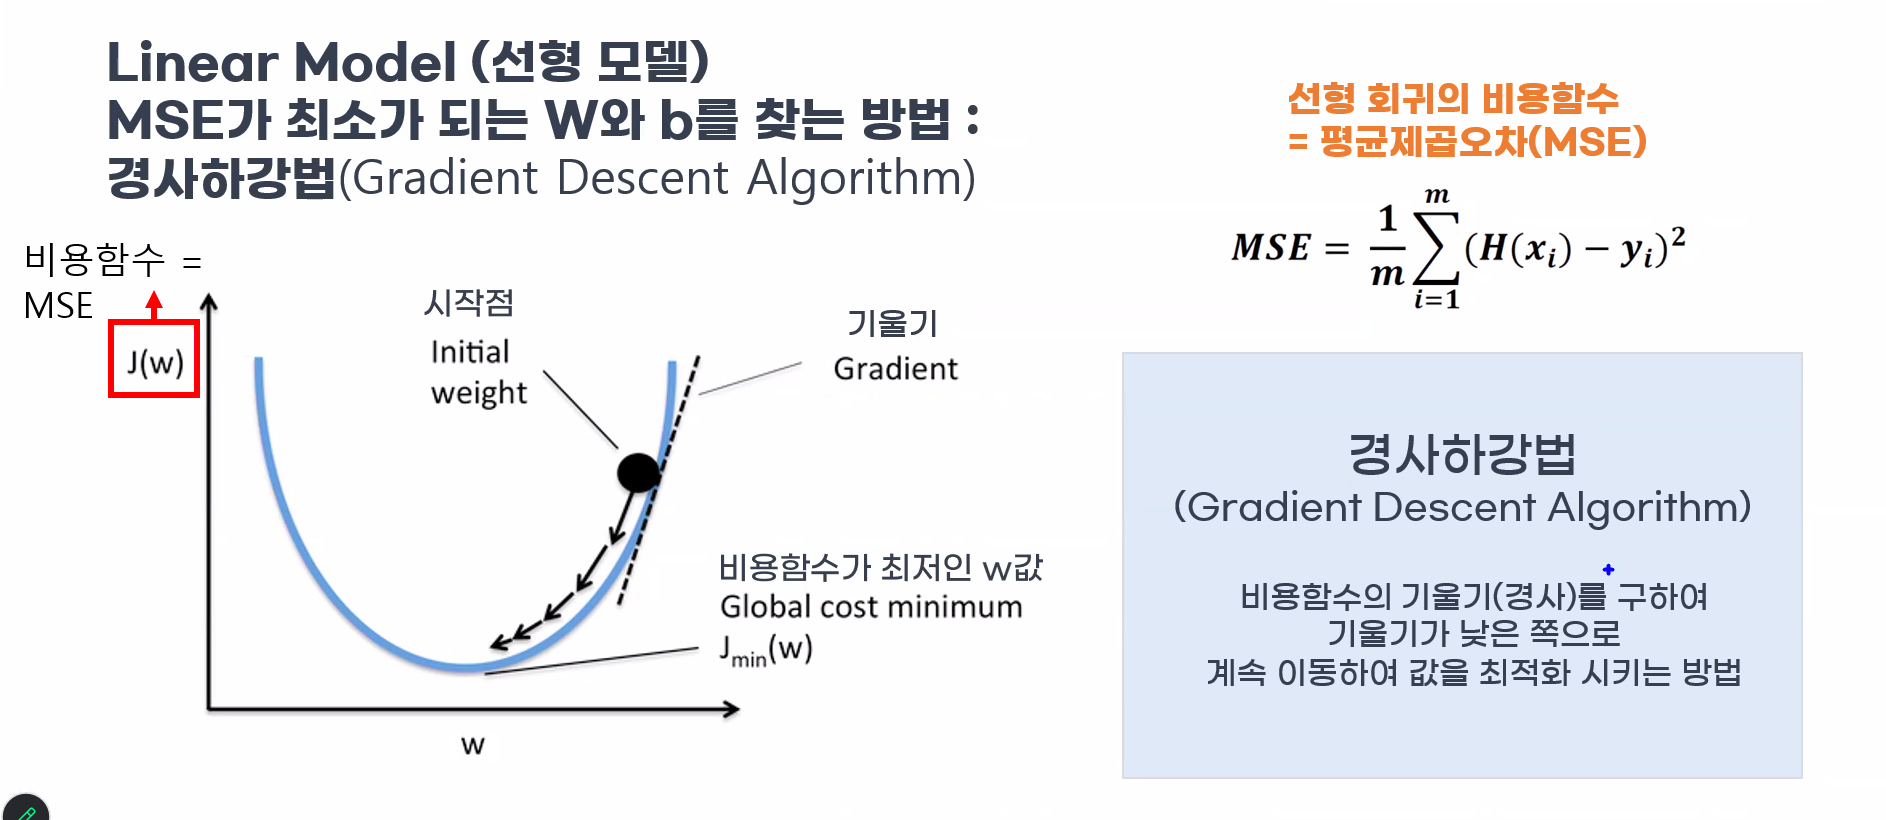

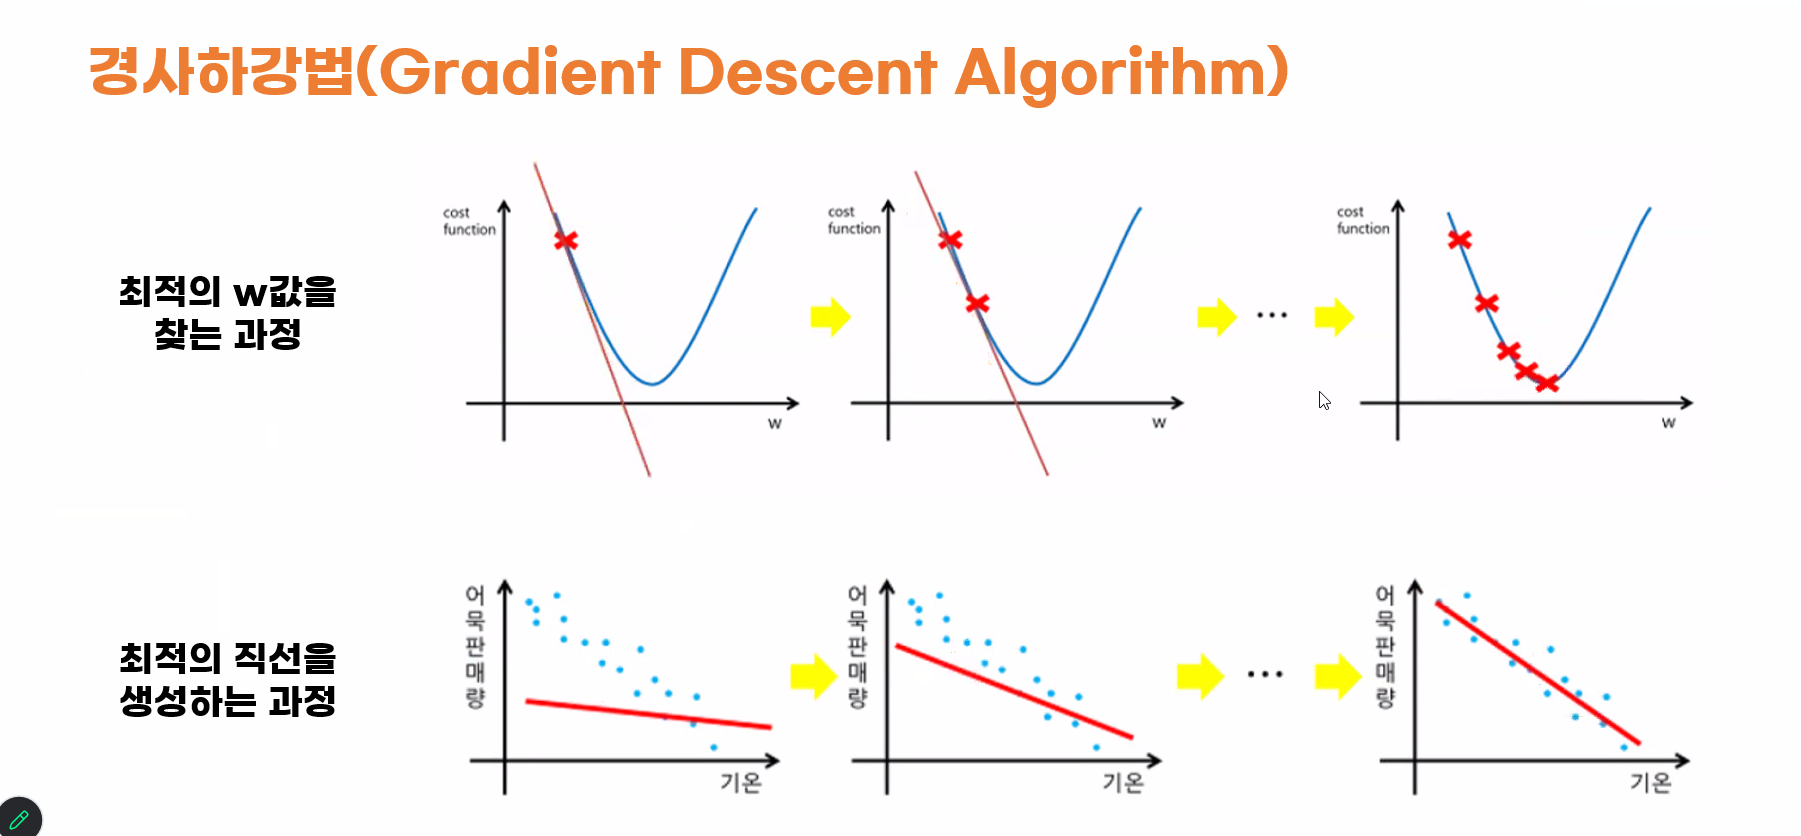

In [15]:
# [경사하강법 그림이 헷갈리는 이유: 두 그래프의 '기울기' 차이]
# 
# 1. 아래쪽 그래프 (실제 데이터의 직선)
# - 여기에서의 기울기(w)는 어묵 판매량과 기온 사이의 '진짜 관계'를 나타냅니다.
# - 데이터가 우하향하므로, 최적의 직선이 되려면 당연히 아래로 향하는 
#   음수(-) 기울기를 가져야 완벽하게 들어맞습니다. (그래서 그림처럼 기울어진 선이 정답이 됩니다.)
# 
# 2. 위쪽 그래프 (오차를 계산하는 U자형 비용함수 그래프)
# - 여기에서의 가로축은 '직선의 기울기(w값)'이고, 세로축은 '오차(Cost)'입니다.
# - 이 U자 곡선 자체의 기울기를 보며 경사를 내려가는 것입니다.
# - U자의 왼쪽 경사면에서는 "오른쪽(아래)으로 가야 오차가 줄어든다"고 판단하고,
#   U자의 오른쪽 경사면에서는 "왼쪽(아래)으로 가야 오차가 줄어든다"고 판단하여
#   결국 U자의 맨 바닥(오차가 가장 작은 최적의 w값)을 찾아내게 됩니다.
# 
# 요약하자면:
# - 아래쪽 그림은 "데이터에 맞는 **완벽한 선의 기울기(w)**를 찾아가는 과정"이고,
# - 위쪽 그림은 "그 최적의 w값을 찾기 위해 **오차의 경사(기울기)**를 타고 내려가는 과정"입니다.

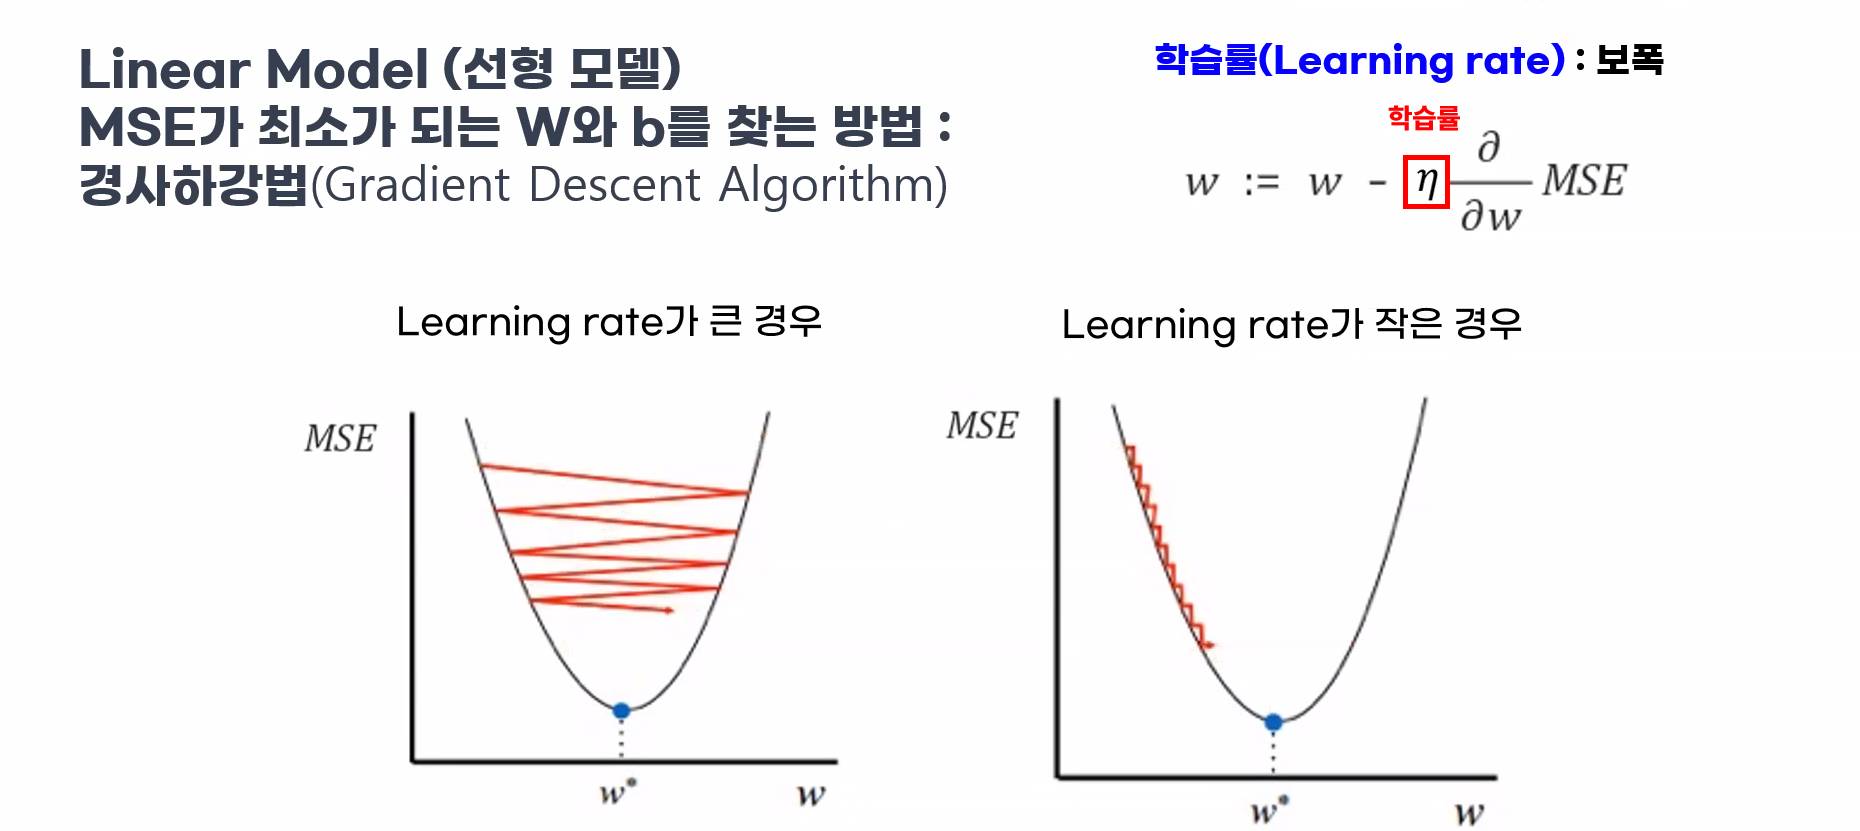

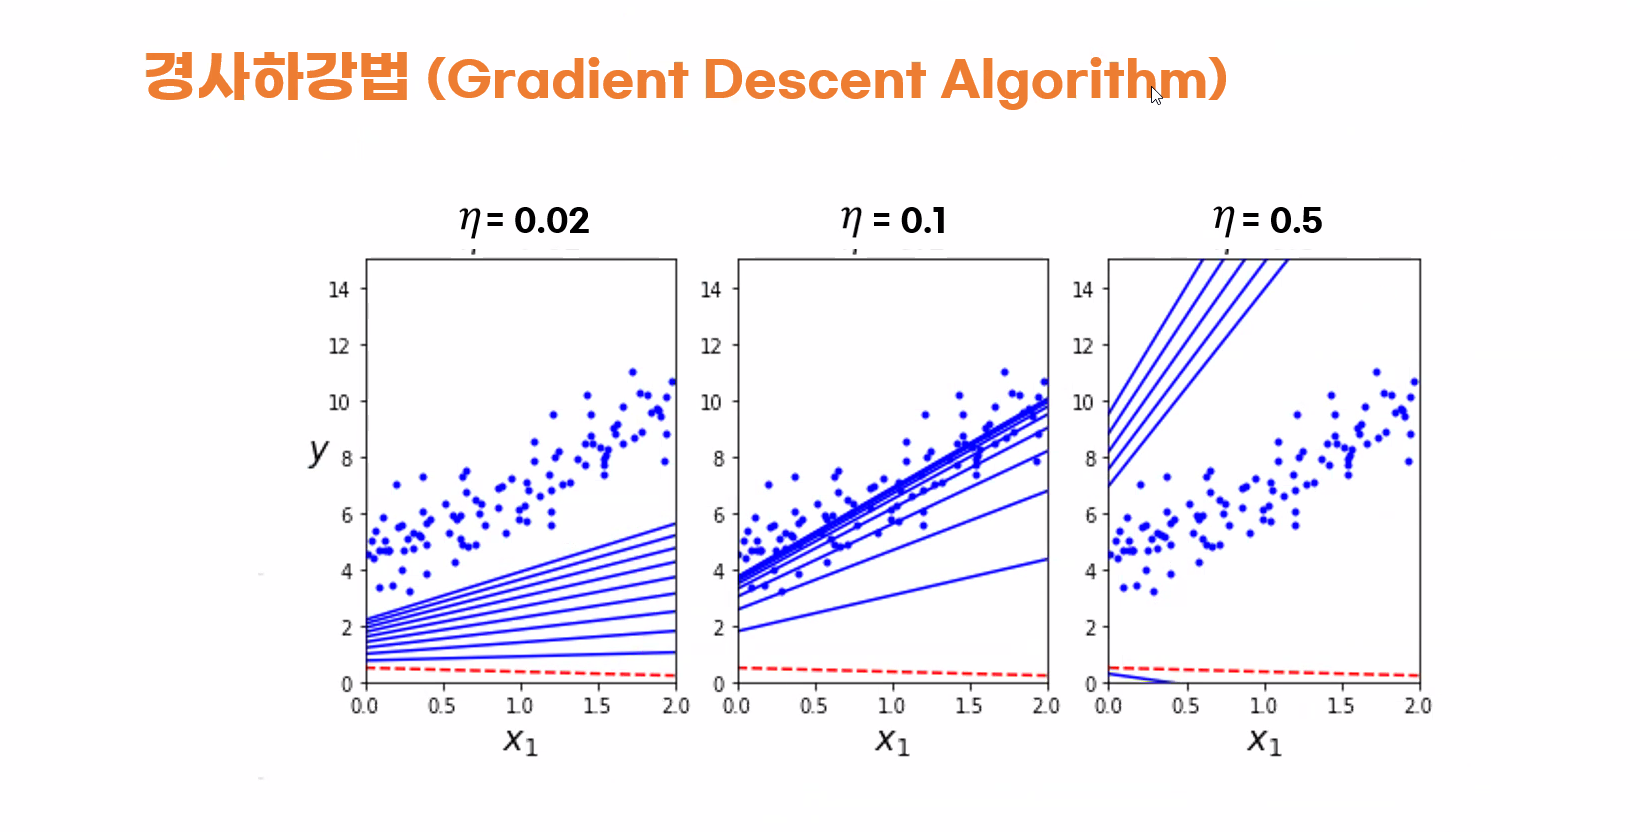

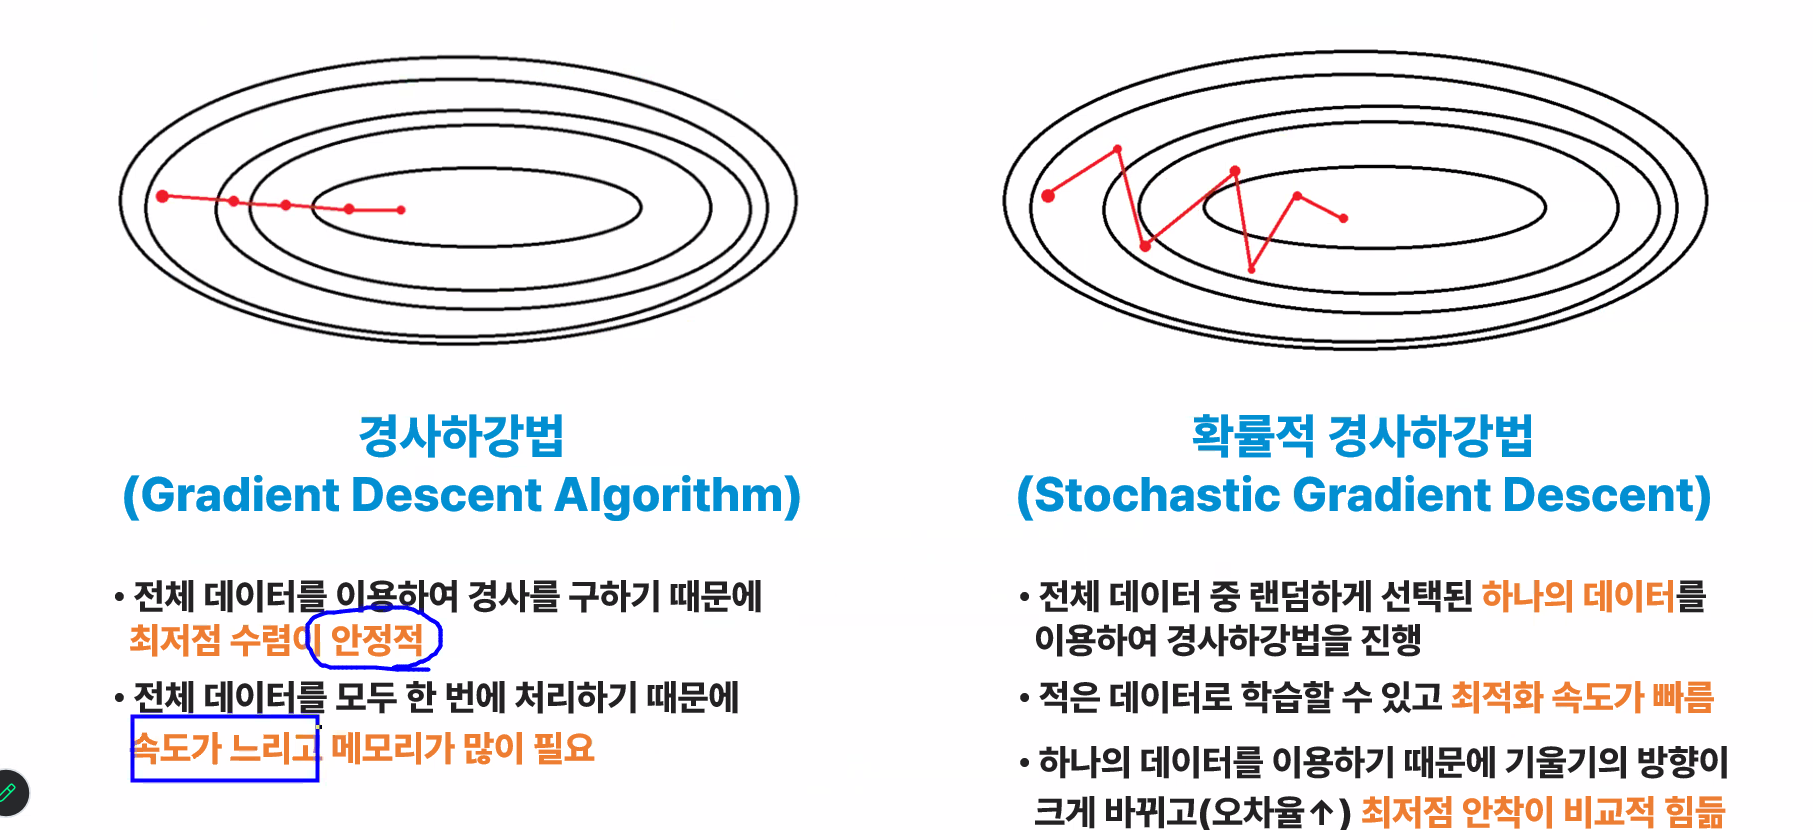

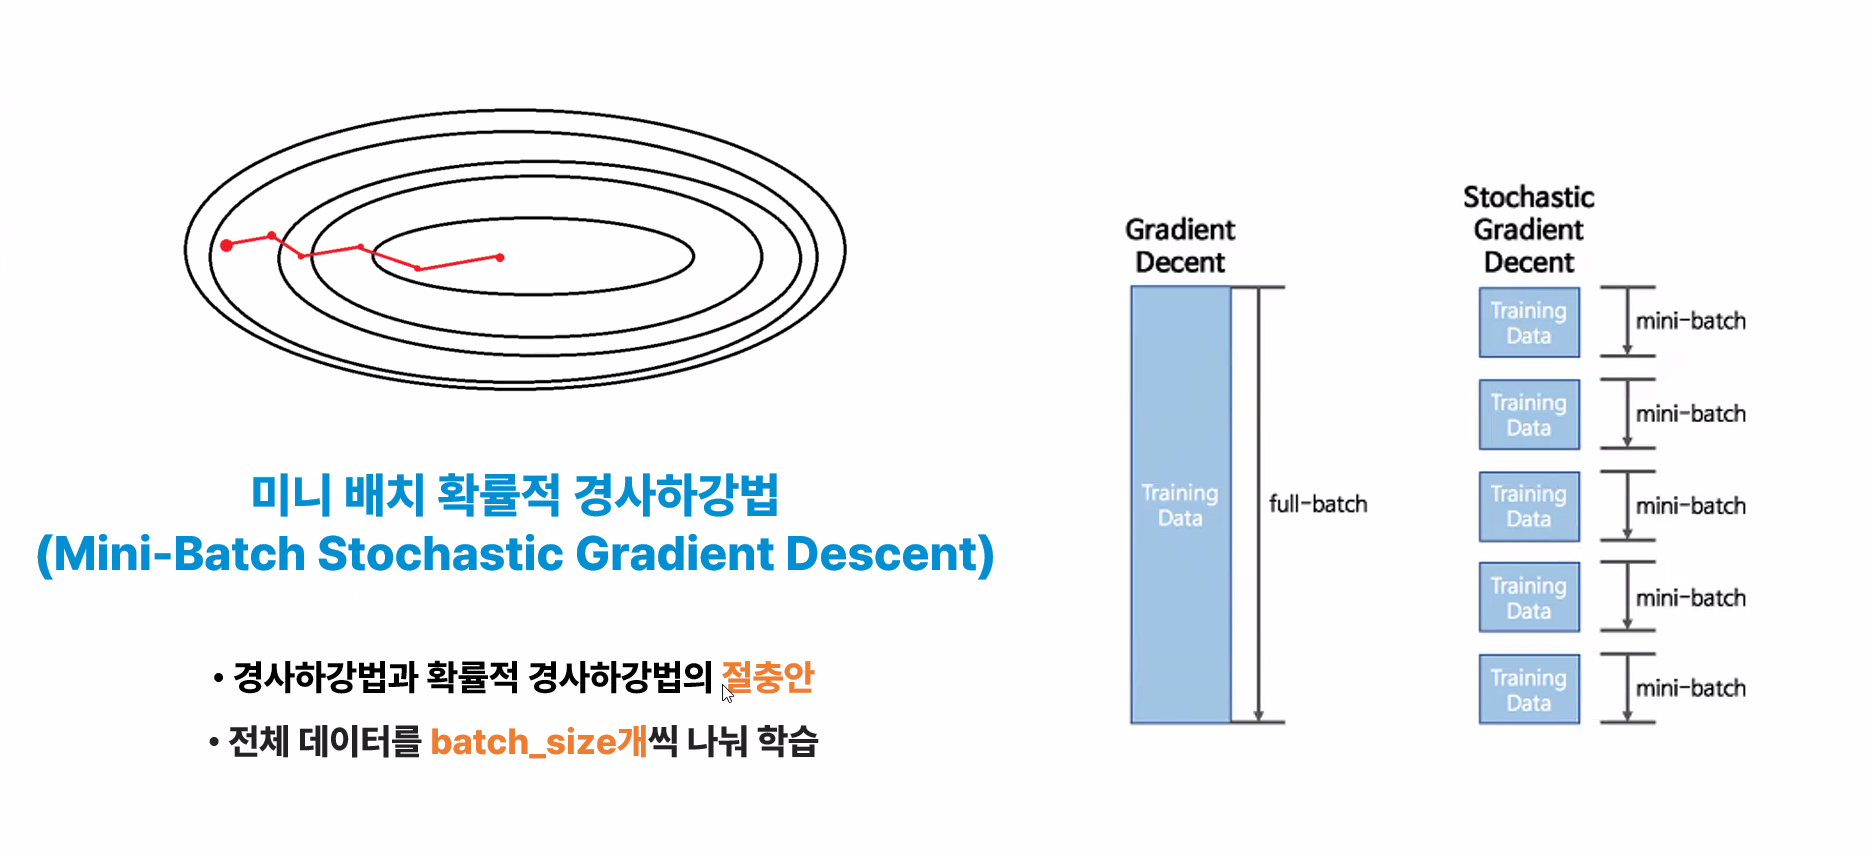

In [17]:
# 예측값
# y = wx +b

# 가설함수 정의(예측 값을 계산하는 가설함수)
def h(w, x) :
    return w * x + 0

In [18]:
# 비용함수 정의 -> MSE
def cost(data, target, weight): # x, y, 가중치
    y_pre = h(weight, data) # 예측값
    # MSE : 오차(예측값 - 실제값)를 제곱해서 평균 내는 것
    return ((y_pre - target) ** 2).mean()
        

In [19]:
# 가중치(weight)마다 MSE가 어떻게 변화하는지 살펴보자 !
# cost(특성값, 실제값, 가중치)
# cost는 내가 정의한 함수이기 때문에 특성값에 대괄호 두개 안써도 된다. - 지금 특성값이 시간 하나 뿐이라서. 여러개 되면 대괄호 두개 써야함.
cost(data['시간'], data['성적'], 10) 

np.float64(0.0)

In [20]:
# 오차의 평균 값이 165
cost(data['시간'], data['성적'], 12) 

np.float64(165.0)

In [22]:
# 가중치가 -10~30까지의 MSE변화를 그려보자!

# 가중치 변수 선언
weight_arr = range(-10, 31)

In [23]:
# 비용함수(MSE)를 담을 리스트 선언
cost_list = []
# 가중치 반복 -> MSE 
for w in weight_arr:
    mse = cost(data['시간'], data['성적'], w)
    cost_list.append(mse)

cost_list

[np.float64(16500.0),
 np.float64(14891.25),
 np.float64(13365.0),
 np.float64(11921.25),
 np.float64(10560.0),
 np.float64(9281.25),
 np.float64(8085.0),
 np.float64(6971.25),
 np.float64(5940.0),
 np.float64(4991.25),
 np.float64(4125.0),
 np.float64(3341.25),
 np.float64(2640.0),
 np.float64(2021.25),
 np.float64(1485.0),
 np.float64(1031.25),
 np.float64(660.0),
 np.float64(371.25),
 np.float64(165.0),
 np.float64(41.25),
 np.float64(0.0),
 np.float64(41.25),
 np.float64(165.0),
 np.float64(371.25),
 np.float64(660.0),
 np.float64(1031.25),
 np.float64(1485.0),
 np.float64(2021.25),
 np.float64(2640.0),
 np.float64(3341.25),
 np.float64(4125.0),
 np.float64(4991.25),
 np.float64(5940.0),
 np.float64(6971.25),
 np.float64(8085.0),
 np.float64(9281.25),
 np.float64(10560.0),
 np.float64(11921.25),
 np.float64(13365.0),
 np.float64(14891.25),
 np.float64(16500.0)]

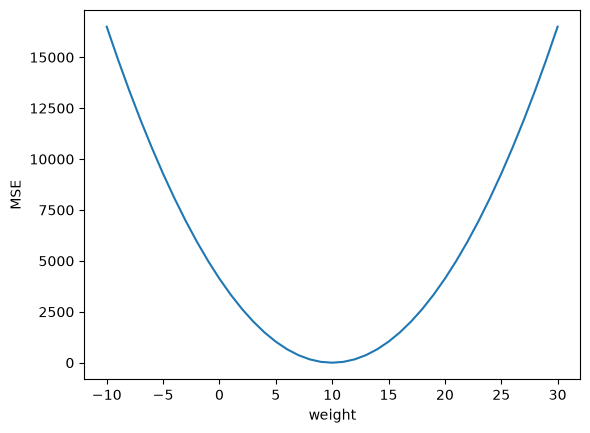

In [24]:
# 그래프 그리기 !
plt.plot(weight_arr, cost_list) # 가중치, 비용함수(MSE)
plt.xlabel('weight')
plt.ylabel('MSE') # loss. 손실함수
plt.show()

#### 경사하강법 SGDRegressor 사용하기

In [25]:
# 모델 불러오기
from sklearn.linear_model import SGDRegressor # 경사하강법 적용 모델

In [26]:
# 모델 생성(초기화)
sgd_model = SGDRegressor(max_iter = 5000, # 가중치 업데이트 반복 횟수(epoch) -> 가중치를 최대 5000번까지만 수정하겠다.
                         eta0 = 0.001, # 학습률(Learning rate)
                         verbose = 1) # 학습 진행 과정을 출력해라!
                         

In [27]:
# 학습
sgd_model.fit(data[['시간']], data['성적'])
# loss를 보자. 경사하강법에 따라 조금씩 줄어든다.

-- Epoch 1
Norm: 1.36, NNZs: 1, Bias: 0.186614, T: 4, Avg. loss: 1872.350703, Objective: 1872.350738
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 2.23, NNZs: 1, Bias: 0.307280, T: 8, Avg. loss: 1433.116657, Objective: 1433.116813
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 2.91, NNZs: 1, Bias: 0.402524, T: 12, Avg. loss: 1163.586476, Objective: 1163.586753
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 3.49, NNZs: 1, Bias: 0.483281, T: 16, Avg. loss: 968.439955, Objective: 968.440464
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 3.99, NNZs: 1, Bias: 0.552639, T: 20, Avg. loss: 814.501144, Objective: 814.501833
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 4.43, NNZs: 1, Bias: 0.613527, T: 24, Avg. loss: 692.313745, Objective: 692.314572
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 4.82, NNZs: 1, Bias: 0.667661, T: 28, Avg. loss: 593.490136, Objective: 593.491201
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 5.17, NNZs: 1, Bias: 0.716023, T: 

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",5000
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",1
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.001
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1


In [28]:
# 가중치와 편향 확인
print(sgd_model.coef_) # w
print(sgd_model.intercept_) # b

[9.79341595]
[1.32894543]


In [30]:
# 예측
sgd_model.predict([[7]])

C:\Users\smhrd\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


array([69.88285707])

In [31]:
# R2 score
sgd_model.score(data[['시간']], data['성적']) # 1에 가까울수록 성능이 좋은 것이다

0.9995489181421433

In [ ]:
# 간단하게 데이터를 만들어서 진행해봤다.
# 선형 회귀모델은 특성(x)가 많을 수록 더 좋은 성능이 발현되는 모델.